In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models
import cv2
import os
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import Input
print('DONE')


DONE


In [ ]:
!unzip '/content/drive/MyDrive/violence_dataset.zip' -d /content/dataset

Archive:  /content/drive/MyDrive/violence_dataset.zip
  inflating: /content/dataset/RWF-2000/train/Fight/-1l5631l3fg_0.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/-1l5631l3fg_1.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/-1l5631l3fg_2.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/0H2s9UJcNJ0_0.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/0H2s9UJcNJ0_2.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/0H2s9UJcNJ0_3.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/0H2s9UJcNJ0_4.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/0H2s9UJcNJ0_5.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/0NWz-01A2yk_0.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/0NWz-01A2yk_1.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/0TFi8D8IBg4_1.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/0_DzLlklZa0_3.avi  
  inflating: /content/dataset/RWF-2000/train/Fight/0_DzLlklZa0_4.avi  
  inflating: /content/d

In [ ]:
import cv2
import os
import random
from tqdm import tqdm

# Output folders
BASE_OUT = "/content/frames"

TRAIN_V  = f"{BASE_OUT}/train/Violence"
TRAIN_NV = f"{BASE_OUT}/train/NonViolence"

VAL_V  = f"{BASE_OUT}/val/Violence"
VAL_NV = f"{BASE_OUT}/val/NonViolence"
for folder in [TRAIN_V, TRAIN_NV, VAL_V, VAL_NV]:
    os.makedirs(folder, exist_ok=True)

# ── Extract frames from one video
def extract_frames(video_path, out_folder, fps=3):
    cap = cv2.VideoCapture(video_path)
    interval = int(cap.get(cv2.CAP_PROP_FPS) / fps)
    name = os.path.splitext(os.path.basename(video_path))[0]
    i = saved = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if i % interval == 0:
            cv2.imwrite(f"{out_folder}/{name}_frame{saved}.jpg", frame)
            saved += 1
        i += 1
    cap.release()

# ── Process a folder of videos
def process(folder, train_out, val_out, val_split=0.2):
    videos = [f for f in os.listdir(folder) if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]
    random.shuffle(videos)

    split = int(len(videos) * val_split)
    val_videos, train_videos = videos[:split], videos[split:]

    for v in tqdm(val_videos,   desc="Val"):
        extract_frames(f"{folder}/{v}", val_out)
    for v in tqdm(train_videos, desc="Train"):
        extract_frames(f"{folder}/{v}", train_out)


RWF  = "/content/dataset/RWF-2000/train"

process(f"{RWF}/Fight",        TRAIN_V,  VAL_V)
process(f"{RWF}/NonFight",     TRAIN_NV, VAL_NV)

print("Done!")

Train: 100%|██████████| 640/640 [02:35<00:00,  4.12it/s]

Done!


In [ ]:
import os

folders = {
    "Train Violence": "/content/frames/train/Violence",
    "Train NonViolence": "/content/frames/train/NonViolence",
    "Val Violence": "/content/frames/val/Violence",
    "Val NonViolence": "/content/frames/val/NonViolence"
}

total = 0

for name, path in folders.items():
    count = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.png', '.jpeg'))])
    print(f"{name}: {count} images")
    total += count

print("\nTotal images:", total)

Train Violence: 9300 images
Train NonViolence: 9600 images
Val Violence: 2325 images
Val NonViolence: 2400 images

Total images: 23625


In [ ]:
# Paths to augmented frames for training and validation
train_dir = '/content/frames/train'
val_dir = '/content/frames/val'
# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 16


"""
   ,
    rotation_range=5,              # Small rotation, up to 5 degrees
    width_shift_range=0.05,        # Small horizontal shift, up to 5% of width
    height_shift_range=0.05,       # Small vertical shift, up to 5% of height
    zoom_range=0.1,                # Slight zoom variation, up to 10%
    fill_mode='nearest'
    """
# Data augmentation and generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)


val_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle= True ,
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
)

Found 18900 images belonging to 2 classes.
Found 4725 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=5,              # stop if no improvement for 5 epochs
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.5026 - loss: 0.8686
Epoch 1: val_loss improved from inf to 0.70518, saving model to best_model.h5


1182/1182 ━━━━━━━━━━━━━━━━━━━━ 425s 324ms/step - accuracy: 0.5026 - loss: 0.8686 - val_accuracy: 0.4815 - val_loss: 0.7052 - learning_rate: 1.0000e-05
Epoch 2/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.5095 - loss: 0.8063
Epoch 2: val_loss did not improve from 0.70518
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 329s 278ms/step - accuracy: 0.5095 - loss: 0.8063 - val_accuracy: 0.5079 - val_loss: 0.7348 - learning_rate: 1.0000e-05
Epoch 3/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.5094 - loss: 0.7798
Epoch 3: val_loss improved from 0.70518 to 0.68220, saving model to best_model.h5


1182/1182 ━━━━━━━━━━━━━━━━━━━━ 331s 280ms/step - accuracy: 0.5094 - loss: 0.7798 - val_accuracy: 0.5619 - val_loss: 0.6822 - learning_rate: 1.0000e-05
Epoch 4/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.5084 - loss: 0.7670
Epoch 4: val_loss improved from 0.68220 to 0.68184, saving model to best_model.h5


1182/1182 ━━━━━━━━━━━━━━━━━━━━ 330s 279ms/step - accuracy: 0.5084 - loss: 0.7670 - val_accuracy: 0.5354 - val_loss: 0.6818 - learning_rate: 1.0000e-05
Epoch 5/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.5120 - loss: 0.7566
Epoch 5: val_loss did not improve from 0.68184
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 340s 287ms/step - accuracy: 0.5120 - loss: 0.7566 - val_accuracy: 0.5109 - val_loss: 0.6957 - learning_rate: 1.0000e-05
Epoch 6/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.5172 - loss: 0.7428
Epoch 6: val_loss did not improve from 0.68184
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 377s 283ms/step - accuracy: 0.5172 - loss: 0.7428 - val_accuracy: 0.4935 - val_loss: 0.7070 - learning_rate: 1.0000e-05
Epoch 7/30
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.5265 - loss: 0.7370
Epoch 7: val_loss did not improve from 0.68184

Epoch 7: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 335s 283ms/step - accuracy:

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Step 1: Evaluate the model using the validation generator
loss, accuracy = model.evaluate(val_generator, verbose=1)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy: {accuracy}")

# Step 2: Generate predictions
predictions = model.predict(val_generator, verbose=1)
predicted_classes = (predictions > 0.5).astype(int).reshape(-1)

# Step 3: Get true labels from the generator
true_classes = val_generator.classes
class_labels = ['Class 0', 'Class 1']

# Step 4: Generate classification report
print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))


296/296 ━━━━━━━━━━━━━━━━━━━━ 23s 78ms/step - accuracy: 0.2891 - loss: 0.7570
Validation Loss: 0.6818447113037109
Validation Accuracy: 0.535449743270874
296/296 ━━━━━━━━━━━━━━━━━━━━ 29s 78ms/step

Classification Report:

              precision    recall  f1-score   support

     Class 0       0.65      0.19      0.29      2400
     Class 1       0.52      0.89      0.65      2325

    accuracy                           0.54      4725
   macro avg       0.58      0.54      0.47      4725
weighted avg       0.58      0.54      0.47      4725



Confusion Matrix:
[[ 455 1945]
 [ 250 2075]]


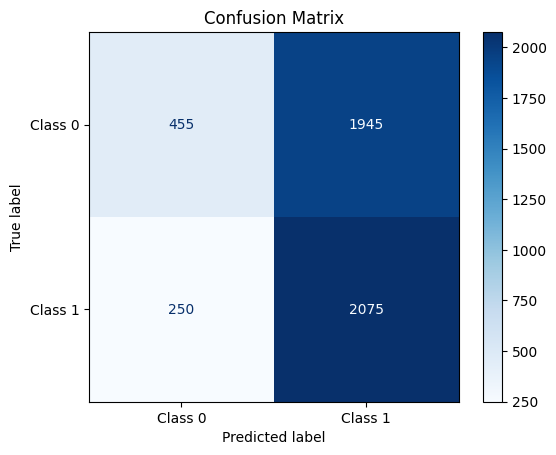

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()